In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [ ]:
import polars as pl
import altair as alt
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from functools import partial
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from utilsforecast.plotting import plot_series as plot_series_utils
from utilsforecast.evaluation import evaluate
from statsforecast.utils import ConformalIntervals
from utilsforecast.losses import mase, rmsse, rmae, spis, nd
from coreforecast.scalers import boxcox, inv_boxcox, boxcox_lambda
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.methods import BottomUp, TopDown, MinTrace
from utilsforecast.feature_engineering import trend, fourier, pipeline
from typing import Callable, Literal, Any, Mapping, Optional, Iterable, Sequence
from polars._typing import IntoExpr
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, BiTCN, LSTM, NHITS
from neuralforecast.auto import AutoNHITS, AutoMLP, AutoBiTCN, AutoLSTM
from neuralforecast.losses.pytorch import DistributionLoss, MAE

# import calendar

# from scipy.stats import pearsonr
# from plotly import express as px
# from pathlib import Path
# from itertools import chain
from datetime import date, timedelta
from itertools import product

import importlib
import lib
import read_data

importlib.reload(lib)

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [3]:
gregorian_year_days = int(365.25)
gregorian_year_weeks = int(gregorian_year_days / 7)
hijri_year_days = int(354.37)
hijri_year_weeks = 51

In [4]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [5]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(Etat="V")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
    .cast({"Id": pl.String})
    .sort("Date_depot")
    .rename({"Poids_global_en_KG": "weight_kg"})
    .drop_nulls("weight_kg")
)

In [10]:
importlib.reload(lib)
base_df = (
    fields
    # .pipe(lib.top_n_or_other, "Centre_Agence_depot", 10, "other_agence")
    # .pipe(lib.top_n_or_other, "Destination", 10, "other_dist")
    .pipe(lib.top_n_or_other, "Centre_Agence_depot", 10)
    .pipe(lib.top_n_or_other, "Destination", 10)
    .with_columns(total=pl.lit("total"))
    .pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight_kg",
        count_col="count",
        mean_col="mean_weight_kg",
        std_col="std_weight_kg",
        # extra_cols=lib.make_relative_hist_cols(
        #     "weight_kg", list(range(32)) + [np.inf], "sum"
        # ),
        group_cols=["Centre_Agence_depot", "Destination", "total"],
    )
)

root_base_df = (
    fields
    .pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight_kg",
        count_col="count",
        mean_col="mean_weight_kg",
        std_col="std_weight_kg",
        # extra_cols=lib.make_relative_hist_cols(
        #     "weight_kg", list(range(32)) + [np.inf], "sum"
        # ),
    )
)

# chart = (
#     alt.Chart(base_df)
#     .mark_line(point=True)
#     .encode(
#         x="Date_depot:T",
#         y=alt.Y("count:Q", scale=alt.Scale(zero=False)),
#         tooltip=["Date_depot:T"],
#     )
#     .properties(width=1100, title="Weekly Mean Weight")
# )
# chart

In [14]:
def transform_timeseries(
    df: pl.DataFrame,
    cols: IntoExpr | Iterable[IntoExpr] = "y",
) -> pl.DataFrame:
    cols_exprs = lib.as_exprs(cols)
    return df.with_columns([col.log1p() for col in cols_exprs])


def untransform_timeseries(
    df: pl.DataFrame,
    cols: IntoExpr | Iterable[IntoExpr] = pl.exclude("unique_id", "ds"),
) -> pl.DataFrame:
    cols_exprs = lib.as_exprs(cols)
    return df.with_columns([col.exp() - 1 for col in cols_exprs])


def calculate_max_n_windows(N, h, season_length, step_size):
    return (N - h - season_length - 1) // step_size


def fake_grouped_fc(
    root_fc: pl.DataFrame,
    grouped_Y_df: pl.DataFrame,
) -> pl.DataFrame:

    return root_fc.pipe(
        lib.complete_grid,
        dimensions={
            "unique_id": grouped_Y_df["unique_id"].unique(),
            "ds": root_fc["ds"].sort().unique(),
        },
        fill_value=0,
    )


def reconcile_forecast(
    root_fc: pd.DataFrame,
    Y_df: pl.DataFrame,
    S_df: pl.DataFrame,
    tags: dict[str, np.ndarray],
):
    raw_fc = pl.DataFrame(
        root_fc,
        schema_overrides={"ds": pl.Date},
    ).pipe(fake_grouped_fc, Y_df)

    recon = HierarchicalReconciliation(reconcilers=[TopDown("proportion_averages")])

    fc = recon.reconcile(
        Y_hat_df=raw_fc.to_pandas(),  # pyright: ignore[reportArgumentType]
        Y_df=Y_df.to_pandas(),  # pyright: ignore[reportArgumentType]
        S_df=S_df.to_pandas(),  # pyright: ignore[reportArgumentType]
        tags=tags,
    )

    return pl.DataFrame(fc)


def unnest_grouped_unique_id(
    df: pl.DataFrame,
    categories: Sequence[str],
) -> pl.DataFrame:
    return (
        df.filter(
            pl.col("unique_id").str.count_matches("/", literal=True) == len(categories)
        )
        .select(
            pl.col("unique_id")
            .str.extract_groups("^.+?/" + "/".join(len(categories) * ["(.+?)"]) + "$")
            .struct.rename_fields(categories)
            .struct.unnest(),
            pl.all(),
        )
        .drop("unique_id")
    )


def with_totals(
    df: pl.DataFrame,
    categories: Sequence[str],
    value_cols: IntoExpr | Iterable[IntoExpr] = pl.selectors.all(),
) -> pl.DataFrame:
    value_cols_exprs = lib.as_exprs(value_cols)

    return (
        pl.concat(
            df.with_columns(
                **{
                    col: pl.lit("all")
                    for col, use_all in zip(categories, mask)
                    if use_all
                }
            )
            for mask in product([True, False], repeat=len(categories))
        )
        .group_by(["ds", "Destination", "Centre_Agence_depot"], maintain_order=True)
        .agg(
            *[value_col.sum() for value_col in value_cols_exprs],
            # pl.selectors.exclude(value_cols_exprs).first(),  # requires the specialized Selector class, not any normal Expr
        )
    )


def sort_by_categories(df, categories):
    return df.sort(
        [
            pl.when(pl.col(category) == "all")
            .then(0)
            .when(pl.col(category) == "other")
            .then(2)
            .otherwise(1)
            for category in categories
        ]
        # + [pl.col(category) for category in categories]
    )

In [ ]:
root_Y_df, root_X_df = (
    root_base_df.select(
        ds=pl.col("Date_depot"),
        y=pl.col("count"),
        unique_id=pl.lit("total"),
    )
    .pipe(transform_timeseries)
    .pipe(
        pipeline,
        [
            trend,
            # partial(fourier, season_length=52, k=5),
        ],
        "1w",
        4,
    )
)


levels: list[int] = [80, 95]
h = 4
# intervals_daily = ConformalIntervals(h=h, n_windows=min(10, len(df_daily) // h))
intervals = ConformalIntervals(h=h, n_windows=10)
cv_step_size = 10
# cv_n_windows_daily = calculate_max_n_windows(
#     len(df_daily), h, hijri_year_weeks, cv_step_size
# )
# cv_n_windows = calculate_max_n_windows(len(df), h, hijri_year_weeks, cv_step_size)
cv_n_windows = 1

In [16]:
sf = StatsForecast(
    freq="1w",
    n_jobs=-1,
    models=[
        SeasonalNaive(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals, # buggy
        ),
    ],
)

In [36]:
nf = NeuralForecast(
    models=[
        # AutoNHITS(
        #     h=4,
        # ),
        # AutoBiTCN(h=4),
        BiTCN(
            **{
                "h": 4,
                "hidden_size": 16,
                "dropout": 0.257496473259851,
                "learning_rate": 0.03308602267865399,
                "scaler_type": "robust",
                "max_steps": 1000,
                "batch_size": 128,
                "windows_batch_size": 512,
                "loss": MAE(),
                "random_seed": 10,
                "input_size": 20,
                "step_size": 4,
                "valid_loss": MAE(),
            }
        ),
        NHITS(
            **{
                "h": 4,
                "n_pool_kernel_size": [2, 2, 2],
                "n_freq_downsample": [24, 12, 1],
                "learning_rate": 0.00017565392237572106,
                "scaler_type": None,
                "max_steps": 1400.0,
                "batch_size": 256,
                "windows_batch_size": 1024,
                "loss": MAE(),
                "random_seed": 17,
                "input_size": 20,
                "step_size": 1,
                "valid_loss": MAE(),
            }
        ),
    ],
    freq="W",
)

Seed set to 10
Seed set to 17


In [ ]:
nf.fit(
    df=root_Y_df.to_pandas(),
)  # pyright: ignore[reportArgumentType]


In [25]:
root_fc = nf.predict(
    h=100,
    # level=levels,
)  # pyright: ignore[reportAssignmentType]

/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

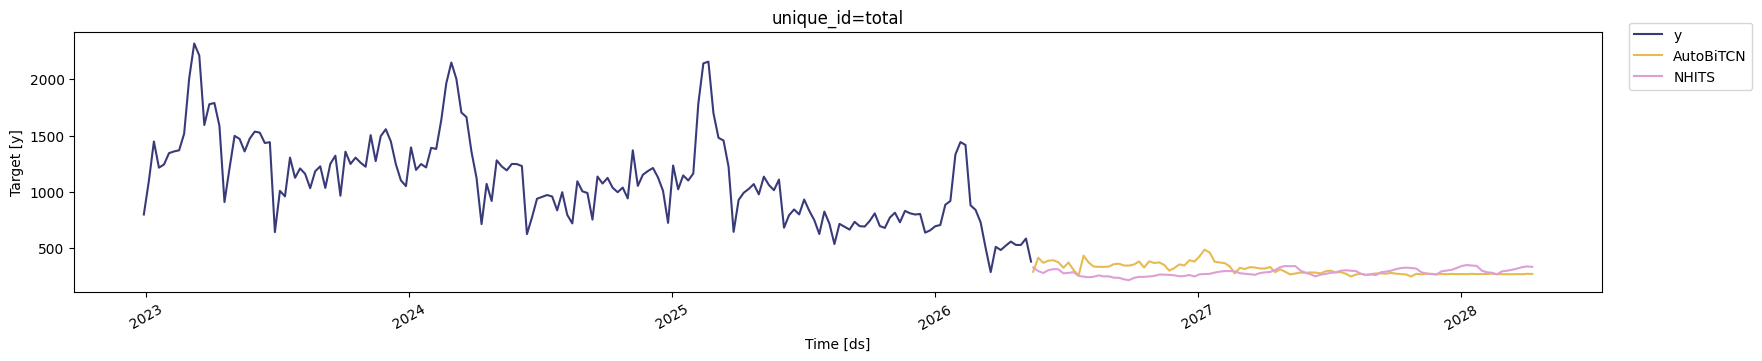

In [29]:
StatsForecast.plot(
    root_Y_df.pipe(untransform_timeseries).to_pandas(),
    pl.DataFrame(root_fc).pipe(untransform_timeseries).to_pandas(),
    # level=levels,  # pyright: ignore[reportArgumentType]
)

In [ ]:
baseline_cv_df = sf.cross_validation(
    h=h,
    df=root_Y_df.to_pandas(),
    n_windows=1,
    step_size=cv_step_size,
    # level=levels,
)

cv_df = nf.cross_validation(
    h=h,
    df=root_Y_df.to_pandas(),
    static_features=[],
    n_windows=1,
    step_size=cv_step_size,
    # level=levels,
)

cv_df["SeasonalNaive"] = baseline_cv_df["SeasonalNaive"]

transformed_cv_df = pl.DataFrame(cv_df).pipe(
    untransform_timeseries,
    pl.exclude("unique_id", "ds", "cutoff"),
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

   | Name          | Type          | Params | Mode 
---------------------------------------------------------
0  | loss          | MAE           | 0      | train
1  | valid_loss    | MAE           | 0      | train
2  | padder_train  | ConstantPad1d | 0      | train
3  | scaler        | TemporalNorm  | 0      | train
4  | lin_hist      | Linear        | 32     | train
5  | drop_hist     | Dropout       | 0      | train
6  | net_bwd       | Sequential    | 5.4 K  | train
7  | drop_temporal | Dropout       | 0      | train
8  | temporal_lin1 | Linear        | 336    | train
9  | temporal_lin2 | Linear        | 68     | train
10 | output_lin    | Linear        | 17     | train
---------------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# transformed_cv_df = transformed_cv_df.with_columns(
#     ensemble=(pl.col("LinearRegression") + pl.col("CatBoostRegressor")) / 2
# )

cv_evaluation = evaluate(
    transformed_cv_df.to_pandas(),
    train_df=Y_df.to_pandas(),
    metrics=[
        partial(mase, seasonality=hijri_year_weeks),
        partial(rmae, baseline="SeasonalNaive"),
        spis,
        nd,
    ],
    # level=levels,
)
print(pl.DataFrame(cv_evaluation))

shape: (10, 14)
┌───────────┬─────────────────────┬────────────────────┬──────────────────┬────────────┬───────────────┬──────────────────┬──────────┬──────────┬───────────────────────────────┬───────────────┬──────────────┬───────────────────┬───────────────┐
│ unique_id ┆ cutoff              ┆ metric             ┆ LinearRegression ┆ ElasticNet ┆ ARDRegression ┆ TweedieRegressor ┆ Lasso    ┆ Ridge    ┆ HistGradientBoostingRegressor ┆ LGBMRegressor ┆ XGBRegressor ┆ CatBoostRegressor ┆ SeasonalNaive │
│ ---       ┆ ---                 ┆ ---                ┆ ---              ┆ ---        ┆ ---           ┆ ---              ┆ ---      ┆ ---      ┆ ---                           ┆ ---           ┆ ---          ┆ ---               ┆ ---           │
│ str       ┆ datetime[ms]        ┆ str                ┆ f64              ┆ f64        ┆ f64           ┆ f64              ┆ f64      ┆ f64      ┆ f64                           ┆ f64           ┆ f64          ┆ f64               ┆ f64           │
╞═══

In [ ]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric", "unique_id")
    .agg(pl.exclude("unique_id", "cutoff", "metric").pipe(lib.exp_weighted_mean, 3))
    # .unpivot(index="metric", variable_name="model", value_name="score")
    # .sort("score")
)

shape: (1, 13)
┌────────────────────┬───────────┬──────────────────┬────────────┬───────────────┬──────────────────┬──────────┬──────────┬───────────────────────────────┬───────────────┬──────────────┬───────────────────┬───────────────┐
│ metric             ┆ unique_id ┆ LinearRegression ┆ ElasticNet ┆ ARDRegression ┆ TweedieRegressor ┆ Lasso    ┆ Ridge    ┆ HistGradientBoostingRegressor ┆ LGBMRegressor ┆ XGBRegressor ┆ CatBoostRegressor ┆ SeasonalNaive │
│ ---                ┆ ---       ┆ ---              ┆ ---        ┆ ---           ┆ ---              ┆ ---      ┆ ---      ┆ ---                           ┆ ---           ┆ ---          ┆ ---               ┆ ---           │
│ str                ┆ str       ┆ f64              ┆ f64        ┆ f64           ┆ f64              ┆ f64      ┆ f64      ┆ f64                           ┆ f64           ┆ f64          ┆ f64               ┆ f64           │
╞════════════════════╪═══════════╪══════════════════╪════════════╪═══════════════╪═══════════

In [ ]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric")
    .agg(pl.exclude("unique_id", "cutoff", "metric").mean())
    .unpivot(index="metric", variable_name="model", value_name="score")
    .sort("score")
)

shape: (11, 3)
┌────────────────────┬───────────────────┬──────────┐
│ metric             ┆ model             ┆ score    │
│ ---                ┆ ---               ┆ ---      │
│ str                ┆ str               ┆ f64      │
╞════════════════════╪═══════════════════╪══════════╡
│ rmae_SeasonalNaive ┆ Ridge             ┆ 0.403761 │
│ rmae_SeasonalNaive ┆ LinearRegression  ┆ 0.414523 │
│ rmae_SeasonalNaive ┆ CatBoostRegressor ┆ 0.436181 │
│ rmae_SeasonalNaive ┆ ARDRegression     ┆ 0.484332 │
│ rmae_SeasonalNaive ┆ XGBRegressor      ┆ 0.513092 │
│ …                  ┆ …                 ┆ …        │
│ rmae_SeasonalNaive ┆ LGBMRegressor     ┆ 0.595673 │
│ rmae_SeasonalNaive ┆ TweedieRegressor  ┆ 0.643977 │
│ rmae_SeasonalNaive ┆ ElasticNet        ┆ 0.685479 │
│ rmae_SeasonalNaive ┆ Lasso             ┆ 0.745938 │
│ rmae_SeasonalNaive ┆ SeasonalNaive     ┆ 1.0      │
└────────────────────┴───────────────────┴──────────┘


In [ ]:
# best_config = {
#     "h": 10,
#     "n_pool_kernel_size": [2, 2, 2],
#     "n_freq_downsample": [24, 12, 1],
#     "learning_rate": 0.00017565392237572106,
#     "scaler_type": None,
#     "max_steps": 1400.0,
#     "batch_size": 256,
#     "windows_batch_size": 1024,
#     "loss": MAE(),
#     "random_seed": 17,
#     "input_size": 20,
#     "step_size": 1,
#     "valid_loss": MAE(),
# }
best_model_h_4 = {
    "h": 4,
    "n_pool_kernel_size": [2, 2, 2],
    "n_freq_downsample": [168, 24, 1],
    "learning_rate": 0.0038527230372795897,
    "scaler_type": "standard",
    "max_steps": 600.0,
    "batch_size": 64,
    "windows_batch_size": 256,
    "loss": MAE(),
    "random_seed": 13,
    "input_size": 16,
    "step_size": 4,
    "valid_loss": MAE(),
}

In [ ]:
# auto_nhits = nf.models[0]   # AutoNHITS instance

# best_config = auto_nhits.results.get_best_result().config
# print(best_config)

In [ ]:
fc = nf.predict(h=100)
sf.plot(df.to_pandas(), fc)

In [ ]:
auto_model = nf.models[0]
best_config = auto_model.results.get_best_result().config
best_config

{'h': 4,
 'hidden_size': 16,
 'dropout': 0.257496473259851,
 'learning_rate': 0.03308602267865399,
 'scaler_type': 'robust',
 'max_steps': 1000,
 'batch_size': 128,
 'windows_batch_size': 512,
 'loss': MAE(),
 'random_seed': 10,
 'input_size': 20,
 'step_size': 4,
 'valid_loss': MAE()}

In [ ]:
long_df = pl.DataFrame(cv_evaluation).unpivot(
    index=["unique_id", "cutoff", "metric"],
    on=pl.selectors.exclude(["unique_id", "cutoff", "metric"]),
    variable_name="model",
    value_name="value",
)

chart = (
    alt.Chart(long_df.to_pandas())
    .mark_line(point=True)
    .encode(
        x=alt.X("cutoff:T", title="Cutoff"),
        y=alt.Y("value:Q", title="RMAE"),
        color=alt.Color("model:N", title="Model"),
        tooltip=["cutoff:T", "model:N", "value:Q"],
    )
    .properties(width=800, height=400, title="RMAE over Cross-validation windows by model")
)

chart

alt.Chart(...)

In [ ]:
pl.DataFrame(cv_evaluation).write_csv("results/neural_cv_evaluation.csv")